In [7]:
import fitz  # PyMuPDF

PDF_PATH = r"/home/son/Desktop/rag/app/data/rag_docs.pdf"


def read_pdf(path: str):
    doc = fitz.open(path)

    print(f"تعداد صفحات: {doc.page_count}")
    print("=" * 80)

    for page_number, page in enumerate(doc, start=1):
        text = page.get_text()

        print(f"\n===== Page {page_number} =====\n")
        print(text[:1000])      # فقط 1000 کاراکتر اول
        print("\n" + "-" * 80)


if __name__ == "__main__":
    read_pdf(PDF_PATH)

FileNotFoundError: no such file: '/home/son/Desktop/rag/app/data/rag_docs.pdf'

In [ ]:
import fitz
import re
from dataclasses import dataclass, field

@dataclass
class Chunk:
    chunk_id: str
    type: str          # "parent" یا "child"
    title: str
    content: str
    parent_id: str | None = None
    page: int = 0

def extract_blocks_with_style(path: str):
    """استخراج بلاک‌ها با اطلاعات فونت"""
    doc = fitz.open(path)
    blocks = []

    for page_num, page in enumerate(doc, start=1):
        # dict mode اطلاعات کامل‌تری میده
        page_dict = page.get_text("dict")

        for block in page_dict["blocks"]:
            if block["type"] != 0:  # فقط text block
                continue

            block_text = ""
            max_font_size = 0

            for line in block["lines"]:
                for span in line["spans"]:
                    block_text += span["text"] + " "
                    max_font_size = max(max_font_size, span["size"])

            block_text = block_text.strip()
            if not block_text:
                continue

            blocks.append({
                "text": block_text,
                "font_size": round(max_font_size, 1),
                "page": page_num
            })

    return blocks

def detect_structure(blocks: list) -> tuple[float, float]:
    """پیدا کردن threshold فونت برای parent و child"""
    sizes = [b["font_size"] for b in blocks]
    sizes_sorted = sorted(set(sizes), reverse=True)

    print("فونت‌سایزهای موجود:", sizes_sorted[:10])

    # معمولاً:
    # بزرگ‌ترین سایز = Parent (عنوان اصلی)
    # سایز دوم = Child (زیرعنوان)
    # بقیه = body text
    parent_threshold = sizes_sorted[0] if len(sizes_sorted) > 0 else 16
    child_threshold = sizes_sorted[1] if len(sizes_sorted) > 1 else 13

    return parent_threshold, child_threshold


In [ ]:
blocks = extract_blocks_with_style(r"D:\rag\app\data\rag_docs.pdf")

# نمایش فونت‌سایز هر بلاک
for b in blocks[:30]:
    print(f"[{b['font_size']}pt | p{b['page']}] {b['text'][:60]}")

[20.0pt | p1] ۱  .  مقدمه و پیشینه
[16.0pt | p1] د ر دنیای امروز، مدل های زبانی بزرگ (LLM) به یکی از پایه های
[16.0pt | p1] شده اند. این مدل ها قادرند متون طبیعی را درک کرده، آن ها را 
[16.0pt | p1] تولید نمایند. با این حال، یکی از بزرگ ترین چالش های این مدل 
[16.0pt | p1] آموزش محدود می شود و دسترسی مستقیمی به داده های جدید، اختصاص
[16.0pt | p1] برای رفع این محدودیت، رویکرد «بازیابی-  افزوده تولید» یاRAG 
[16.0pt | p1] Generation)   مطرح شد. این رویکرد ترکیبی از دو مرحله اصلی اس
[16.0pt | p1] 1.   در مرحله اول، اطالعات مرتبط از یک پایگاه دانش بیرونی با
[16.0pt | p1] 2.   در مرحله دوم، مدل زبانی از این اطالعات بازیابی شده به ع
[16.0pt | p1] تا پاسخ نهایی را تولید نماید.
[16.0pt | p1] معماری RAG   نخستین بار توسط لوئیس و همکارانش   در سال۲۰۲۰  
[16.0pt | p1] تحوالت گسترده ای را تجربه کرده است. امروزه این معماری در طیف
[16.0pt | p1] پرسش و پاسخ سازمانی، چت بات های پشتیبانی مشتری، تحلیل اسناد 
[16.0pt | p1] هوش تجاری (BI) مورد استفاده قرار می گیرد.
[20.0pt | p2] ۲ . اجزای اصلی یک سیستم   

In [ ]:
import fitz
import re
from dataclasses import dataclass, field

@dataclass
class Chunk:
    chunk_id: str
    type: str           # "parent" یا "child"
    title: str
    content: str
    parent_id: str | None = None
    page: int = 0

# --- Pattern های شناسایی عنوان ---

# Parent: ۱ . عنوان  یا  ۲ . عنوان  (عدد فارسی + نقطه)
PARENT_PATTERN = re.compile(
    r'^[\u06F0-\u06F9۰-۹\d]+\s*[\.\．]\s+\S'
)

# Child numeric: ۲.۱ عنوان  یا  2.1 عنوان
CHILD_NUMERIC_PATTERN = re.compile(
    r'^[\u06F0-\u06F9۰-۹\d]+[\.\．][\u06F0-\u06F9۰-۹\d]+\s+\S'
)

# Child alphabetic: الف)  ب)  ج)  یا  a)  b)
CHILD_ALPHA_PATTERN = re.compile(
    r'^(الف|ب|پ|ت|ث|ج|چ|[a-zA-Z])\s*[\)\]]\s+\S'
)

def classify_block(text: str, font_size: float) -> str:
    """تشخیص نوع بلاک"""
    text = text.strip()

    if font_size >= 19.0:
        return "parent"

    if CHILD_NUMERIC_PATTERN.match(text):
        return "child"

    if CHILD_ALPHA_PATTERN.match(text):
        return "child"

    return "body"


def extract_blocks_with_style(path: str) -> list[dict]:
    doc = fitz.open(path)
    blocks = []

    for page_num, page in enumerate(doc, start=1):
        page_dict = page.get_text("dict")

        for block in page_dict["blocks"]:
            if block["type"] != 0:
                continue

            block_text = ""
            max_font_size = 0

            for line in block["lines"]:
                for span in line["spans"]:
                    block_text += span["text"] + " "
                    max_font_size = max(max_font_size, span["size"])

            block_text = block_text.strip()
            if not block_text:
                continue

            blocks.append({
                "text": block_text,
                "font_size": round(max_font_size, 1),
                "page": page_num,
                "type": classify_block(block_text, max_font_size)
            })

    return blocks


def build_chunks(path: str) -> list[Chunk]:
    blocks = extract_blocks_with_style(path)

    chunks: list[Chunk] = []
    current_parent: Chunk | None = None
    current_child: Chunk | None = None
    parent_counter = 0
    child_counter = 0

    def flush_child():
        nonlocal current_child
        if current_child:
            chunks.append(current_child)
            current_child = None

    for block in blocks:
        btype = block["type"]
        text  = block["text"]
        page  = block["page"]

        if btype == "parent":
            flush_child()
            if current_parent:
                chunks.append(current_parent)

            parent_counter += 1
            current_parent = Chunk(
                chunk_id=f"parent_{parent_counter}",
                type="parent",
                title=text,
                content=text,
                page=page
            )

        elif btype == "child":
            flush_child()
            child_counter += 1
            current_child = Chunk(
                chunk_id=f"child_{child_counter}",
                type="child",
                title=text,
                content=text,
                parent_id=current_parent.chunk_id if current_parent else None,
                page=page
            )

        else:  # body
            if current_child:
                current_child.content += "\n" + text
            elif current_parent:
                current_parent.content += "\n" + text

    flush_child()
    if current_parent:
        chunks.append(current_parent)

    return chunks

In [ ]:
chunks = build_chunks(r"D:\rag\app\data\rag_docs.pdf")

for c in chunks:
    indent = "  └─" if c.type == "child" else "■"
    print(f"{indent} [{c.type}] {c.title[:60]}")
    print(f"     parent_id={c.parent_id} | page={c.page} | len={len(c.content)}")
    print()

■ [parent] ۱  .  مقدمه و پیشینه
     parent_id=None | page=1 | len=1030

  └─ [child] ۲.۱  پردازش و بارگذاری اسناد   (Document Ingestion)
     parent_id=parent_2 | page=2 | len=417

  └─ [child] ۲.۲  تقسیم بندی متن (Chunking)
     parent_id=parent_2 | page=2 | len=227

  └─ [child] الف) تقسیم بندی با اندازه ثابت (Fixed-size Chunking)
     parent_id=parent_2 | page=2 | len=245

  └─ [child] ب) تقسیم بندی معنایی (Semantic Chunking)
     parent_id=parent_2 | page=3 | len=242

  └─ [child] ج) تقسیم بندی با هم پوشانی (Overlapping Chunks)
     parent_id=parent_2 | page=3 | len=276

  └─ [child] ۲.۳    تبدیل به بردار (Embedding)
     parent_id=parent_2 | page=3 | len=637

  └─ [child] ۲.۴  پایگاه داده برداری (Vector Store)
     parent_id=parent_2 | page=4 | len=1112

  └─ [child] ۲.۶    تولید پاسخ (Generation)
     parent_id=parent_2 | page=5 | len=363

■ [parent] ۲ . اجزای اصلی یک سیستم   RAG
     parent_id=None | page=2 | len=134

  └─ [child] ۳.۱    چندریختی متن فارسی
     parent_id=parent

In [ ]:
import re

CHILD_NUMERIC_PATTERN = re.compile(
    r'^[\u06F0-\u06F9۰-۹\d]+[\.\．][\u06F0-\u06F9۰-۹\d]+\s+\S'
)

def classify_block(text: str, font_size: float) -> str:
    text = text.strip()
    if font_size >= 19.0:
        return "parent"
    if CHILD_NUMERIC_PATTERN.match(text):
        return "child"
    return "body"  # الف) ب) و بقیه همه body

In [ ]:
def build_chunks(path: str) -> list[Chunk]:
    blocks = extract_blocks_with_style(path)

    chunks: list[Chunk] = []
    current_parent: Chunk | None = None
    current_child: Chunk | None = None
    parent_counter = 0
    child_counter = 0

    def flush_child():
        nonlocal current_child
        if current_child:
            chunks.append(current_child)
            current_child = None

    def get_or_create_auto_child(page: int) -> Chunk:
        """اگه parent بدون child داره body می‌گیره، یه child خودکار بساز"""
        nonlocal current_child, child_counter
        if current_child is None and current_parent is not None:
            child_counter += 1
            current_child = Chunk(
                chunk_id=f"child_{child_counter}",
                type="child",
                title=current_parent.title,  # عنوان همون parent
                content="",
                parent_id=current_parent.chunk_id,
                page=page
            )
        return current_child

    for block in blocks:
        btype = block["type"]
        text  = block["text"]
        page  = block["page"]

        if btype == "parent":
            flush_child()
            if current_parent:
                chunks.append(current_parent)

            parent_counter += 1
            current_parent = Chunk(
                chunk_id=f"parent_{parent_counter}",
                type="parent",
                title=text,
                content=text,
                page=page
            )

        elif btype == "child":
            flush_child()
            child_counter += 1
            current_child = Chunk(
                chunk_id=f"child_{child_counter}",
                type="child",
                title=text,
                content=text,
                parent_id=current_parent.chunk_id if current_parent else None,
                page=page
            )

        else:  # body
            target = get_or_create_auto_child(page)
            if target:
                target.content += "\n" + text

    flush_child()
    if current_parent:
        chunks.append(current_parent)

    return chunks

In [ ]:
chunks = build_chunks(r"D:\rag\app\data\rag_docs.pdf")

for c in chunks:
    indent = "  └─" if c.type == "child" else "■"
    print(f"{indent} [{c.type}] {c.title[:60]}")
    print(f"     parent_id={c.parent_id} | page={c.page} | len={len(c.content)}")
    print()

  └─ [child] ۱  .  مقدمه و پیشینه
     parent_id=parent_1 | page=1 | len=1010

■ [parent] ۱  .  مقدمه و پیشینه
     parent_id=None | page=1 | len=20

  └─ [child] ۲ . اجزای اصلی یک سیستم   RAG
     parent_id=parent_2 | page=2 | len=105

  └─ [child] ۲.۱  پردازش و بارگذاری اسناد   (Document Ingestion)
     parent_id=parent_2 | page=2 | len=417

  └─ [child] ۲.۲  تقسیم بندی متن (Chunking)
     parent_id=parent_2 | page=2 | len=227

  └─ [child] الف) تقسیم بندی با اندازه ثابت (Fixed-size Chunking)
     parent_id=parent_2 | page=2 | len=245

  └─ [child] ب) تقسیم بندی معنایی (Semantic Chunking)
     parent_id=parent_2 | page=3 | len=242

  └─ [child] ج) تقسیم بندی با هم پوشانی (Overlapping Chunks)
     parent_id=parent_2 | page=3 | len=276

  └─ [child] ۲.۳    تبدیل به بردار (Embedding)
     parent_id=parent_2 | page=3 | len=637

  └─ [child] ۲.۴  پایگاه داده برداری (Vector Store)
     parent_id=parent_2 | page=4 | len=1112

  └─ [child] ۲.۶    تولید پاسخ (Generation)
     parent_id=parent

In [ ]:
from dataclasses import dataclass, field
import fitz
import re

@dataclass
class ChildChunk:
    id: str
    title: str
    content: str
    parent_id: str

@dataclass
class ParentChunk:
    id: str
    title: str
    content: str
    children: list[ChildChunk] = field(default_factory=list)


CHILD_NUMERIC_PATTERN = re.compile(
    r'^[\u06F0-\u06F9۰-۹\d]+[\.\．][\u06F0-\u06F9۰-۹\d]+\s+\S'
)

def classify_block(text: str, font_size: float) -> str:
    if font_size >= 19.0:
        return "parent"
    if CHILD_NUMERIC_PATTERN.match(text.strip()):
        return "child"
    return "body"

def extract_blocks(path: str) -> list[dict]:
    doc = fitz.open(path)
    blocks = []
    for page_num, page in enumerate(doc, start=1):
        for block in page.get_text("dict")["blocks"]:
            if block["type"] != 0:
                continue
            text, max_size = "", 0
            for line in block["lines"]:
                for span in line["spans"]:
                    text += span["text"] + " "
                    max_size = max(max_size, span["size"])
            text = text.strip()
            if text:
                blocks.append({"text": text, "font_size": round(max_size, 1),
                                "page": page_num, "type": classify_block(text, max_size)})
    return blocks

def build_chunks(path: str) -> list[ParentChunk]:
    blocks = extract_blocks(path)

    parents: list[ParentChunk] = []
    current_parent: ParentChunk | None = None
    current_child: ChildChunk | None = None
    parent_counter = 0
    child_counter = 0

    def flush_child():
        nonlocal current_child
        if current_child and current_parent:
            current_parent.children.append(current_child)
            current_parent.content += "\n" + current_child.content
            current_child = None

    def get_or_create_auto_child(text: str):
        nonlocal current_child, child_counter
        if current_child is None and current_parent is not None:
            child_counter += 1
            current_child = ChildChunk(
                id=f"{current_parent.id}.0",
                title=current_parent.title,
                content="",
                parent_id=current_parent.id
            )

    for block in blocks:
        btype, text = block["type"], block["text"]

        if btype == "parent":
            flush_child()
            if current_parent:
                parents.append(current_parent)
            parent_counter += 1
            current_parent = ParentChunk(
                id=str(parent_counter),
                title=text,
                content=""
            )

        elif btype == "child":
            flush_child()
            child_counter += 1
            current_child = ChildChunk(
                id=f"{current_parent.id}.{child_counter}" if current_parent else str(child_counter),
                title=text,
                content=text,
                parent_id=current_parent.id if current_parent else ""
            )

        else:  # body
            get_or_create_auto_child(text)
            if current_child:
                current_child.content += "\n" + text

    flush_child()
    if current_parent:
        parents.append(current_parent)

    return parents

In [ ]:
def build_chunks(path: str) -> list[ParentChunk]:
    blocks = extract_blocks(path)

    parents: list[ParentChunk] = []
    current_parent: ParentChunk | None = None
    current_child: ChildChunk | None = None
    parent_counter = 0
    child_counter = 0  # ریست میشه برای هر parent

    def flush_child():
        nonlocal current_child
        if current_child and current_parent:
            current_parent.children.append(current_child)
            current_parent.content += "\n" + current_child.content
            current_child = None

    def get_or_create_auto_child(text: str):
        nonlocal current_child, child_counter
        if current_child is None and current_parent is not None:
            child_counter += 1
            current_child = ChildChunk(
                id=f"{current_parent.id}.{child_counter}",
                title=current_parent.title,
                content="",
                parent_id=current_parent.id
            )

    for block in blocks:
        btype, text = block["type"], block["text"]

        if btype == "parent":
            flush_child()
            if current_parent:
                parents.append(current_parent)
            parent_counter += 1
            child_counter = 0  # ← اینجا ریست میشه
            current_parent = ParentChunk(
                id=str(parent_counter),
                title=text,
                content=""
            )

        elif btype == "child":
            flush_child()
            child_counter += 1
            current_child = ChildChunk(
                id=f"{current_parent.id}.{child_counter}" if current_parent else str(child_counter),
                title=text,
                content=text,
                parent_id=current_parent.id if current_parent else ""
            )

        else:  # body
            get_or_create_auto_child(text)
            if current_child:
                current_child.content += "\n" + text

    flush_child()
    if current_parent:
        parents.append(current_parent)

    return parents

In [ ]:
def build_chunks(path: str) -> list[ParentChunk]:
    blocks = extract_blocks(path)

    parents: list[ParentChunk] = []

    current_parent: ParentChunk | None = None
    current_child: ChildChunk | None = None

    parent_counter = 0
    child_counter = 0  # برای هر Parent از 1 شروع می‌شود

    def flush_child():
        nonlocal current_child

        if current_parent is None or current_child is None:
            return

        current_parent.children.append(current_child)
        current_parent.content += "\n" + current_child.content
        current_child = None

    def get_or_create_auto_child():
        nonlocal current_child, child_counter

        if current_parent is None or current_child is not None:
            return

        child_counter += 1

        current_child = ChildChunk(
            id=f"{current_parent.id}.{child_counter}",
            title=current_parent.title,
            content="",
            parent_id=current_parent.id,
        )

    for block in blocks:
        btype = block["type"]
        text = block["text"]

        # ---------------- Parent ----------------
        if btype == "parent":
            flush_child()

            if current_parent is not None:
                parents.append(current_parent)

            parent_counter += 1
            child_counter = 0  # ریست شماره Childها برای Parent جدید

            current_parent = ParentChunk(
                id=str(parent_counter),
                title=text,
                content="",
            )

        # ---------------- Child ----------------
        elif btype == "child":
            if current_parent is None:
                continue

            flush_child()

            child_counter += 1

            current_child = ChildChunk(
                id=f"{current_parent.id}.{child_counter}",
                title=text,
                content=text,
                parent_id=current_parent.id,
            )

        # ---------------- Body ----------------
        else:
            if current_parent is None:
                continue

            get_or_create_auto_child()

            current_child.content += "\n" + text

    flush_child()

    if current_parent is not None:
        parents.append(current_parent)

    return parents

In [3]:
import re
from app.models.Chunks import ChildChunk, ParentChunk
import fitz

CHILD_NUMERIC_PATTERN = re.compile(
    r'^[\u06F0-\u06F9۰-۹\d]+[\.\．][\u06F0-\u06F9۰-۹\d]+\s+\S'
)

def classify_block(text: str, font_size: float) -> str:
    text = text.strip()
    if font_size >= 19.0:
        return "parent"
    if CHILD_NUMERIC_PATTERN.match(text):
        return "child"
    return "body"  # الف) ب) و بقیه همه body

TITLE_PREFIX_PATTERN = re.compile(
    r"^\s*[\d۰-۹]+(?:[\.．][\d۰-۹]+)*\s*[\.．]?\s*"
)

def clean_title(title: str) -> str:
    """شماره ابتدای عنوان (مثل ۵. یا ۳.۲.) را حذف می‌کند."""
    return TITLE_PREFIX_PATTERN.sub("", title).strip()



def extract_blocks(path: str) -> list[dict]:
    doc = fitz.open(path)
    blocks = []
    for page_num, page in enumerate(doc, start=1):
        for block in page.get_text("dict")["blocks"]:
            if block["type"] != 0:
                continue
            text, max_size = "", 0
            for line in block["lines"]:
                for span in line["spans"]:
                    text += span["text"] + " "
                    max_size = max(max_size, span["size"])
            text = text.strip()
            if text:
                blocks.append({"text": text, "font_size": round(max_size, 1),
                                "page": page_num, "type": classify_block(text, max_size)})
    return blocks



def build_chunks(path: str) -> list[ParentChunk]:
    blocks = extract_blocks(path)

    parents: list[ParentChunk] = []

    current_parent: ParentChunk | None = None
    current_child: ChildChunk | None = None

    parent_counter = 0
    child_counter = 0

    # متن‌های قبل از اولین Child واقعی
    pending_body: list[str] = []

    # آیا این Parent حداقل یک Child واقعی دارد؟
    has_real_child = False

    def flush_child():
        nonlocal current_child

        if current_parent is None or current_child is None:
            return

        current_parent.children.append(current_child)
        current_parent.content += "\n" + current_child.content
        current_child = None

    def flush_pending_as_intro():
        """متن‌های قبل از اولین Child واقعی را به عنوان مقدمه ذخیره می‌کند."""
        nonlocal child_counter

        if current_parent is None or not pending_body:
            return

        child_counter += 1

        intro = ChildChunk(
            id=f"{current_parent.id}.{child_counter}",
            title=f"مقدمه: {current_parent.title}",
            content="\n".join(pending_body),
            parent_id=current_parent.id,
        )

        current_parent.children.append(intro)
        current_parent.content += "\n" + intro.content

        pending_body.clear()

    def flush_pending_as_single_child():
        """اگر Parent هیچ Child واقعی نداشت، کل متن را یک Child می‌کند."""
        nonlocal child_counter

        if current_parent is None or not pending_body:
            return

        child_counter += 1

        only_child = ChildChunk(
            id=f"{current_parent.id}.{child_counter}",
            title=current_parent.title,
            content="\n".join(pending_body),
            parent_id=current_parent.id,
        )

        current_parent.children.append(only_child)
        current_parent.content += "\n" + only_child.content

        pending_body.clear()

    for block in blocks:

        btype = block["type"]
        text = block["text"]

        # ---------------- Parent ----------------
        if btype == "parent":

            flush_child()

            if current_parent is not None:

                if not has_real_child:
                    flush_pending_as_single_child()

                parents.append(current_parent)

            parent_counter += 1
            child_counter = 0

            current_parent = ParentChunk(
                id=str(parent_counter),
                title=clean_title(text),   # ← عنوان Parent بدون شماره
                content="",
            )

            pending_body.clear()
            has_real_child = False

        # ---------------- Child ----------------
        elif btype == "child":

            if current_parent is None:
                continue

            if not has_real_child:
                flush_pending_as_intro()

            has_real_child = True

            flush_child()

            child_counter += 1

            current_child = ChildChunk(
                id=f"{current_parent.id}.{child_counter}",
                title=clean_title(text),   # ← عنوان Child بدون شماره
                content=text,              # متن اصلی بدون تغییر
                parent_id=current_parent.id,
            )

        # ---------------- Body ----------------
        else:

            if current_parent is None:
                continue

            if not has_real_child and current_child is None:
                pending_body.append(text)
            else:
                if current_child is not None:
                    current_child.content += "\n" + text

    flush_child()

    if current_parent is not None:

        if not has_real_child:
            flush_pending_as_single_child()

        parents.append(current_parent)

    return parents

In [4]:
from app.utils.Parser import build_chunks
parents = build_chunks(r"D:\rag\app\data\rag_docs.pdf")

for p in parents:
    print(f"\n■ [parent {p.id}] {p.title[:50]}")
    for c in p.children:
        print(f"  └─ [child {c.id}] {c.title[:50]}")


■ [parent 1] مقدمه و پیشینه
  └─ [child 1.1] مقدمه و پیشینه

■ [parent 2] اجزای اصلی یک سیستم   RAG
  └─ [child 2.1] مقدمه ای برای: اجزای اصلی یک سیستم   RAG
  └─ [child 2.2] پردازش و بارگذاری اسناد   (Document Ingestion)
  └─ [child 2.3] تقسیم بندی متن (Chunking)
  └─ [child 2.4] تبدیل به بردار (Embedding)
  └─ [child 2.5] پایگاه داده برداری (Vector Store)
  └─ [child 2.6] بازیابی و رتبه بندی (Retrieval & Reranking)
  └─ [child 2.7] تولید پاسخ (Generation)

■ [parent 3] چالش های RAG برای زبان فارسی
  └─ [child 3.1] مقدمه ای برای: چالش های RAG برای زبان فارسی
  └─ [child 3.2] چندریختی متن فارسی
  └─ [child 3.3] اتصال کلمات و توکن بندی
  └─ [child 3.4] کمبود داده های آموزشی
  └─ [child 3.5] راست به چپ بودن متن

■ [parent 4] معیارهای ارزیابی   RAG
  └─ [child 4.1] مقدمه ای برای: معیارهای ارزیابی   RAG
  └─ [child 4.2] دقت بازیابی   (Retrieval Accuracy)
  └─ [child 4.3] کیفیت تولید (Generation Quality)
  └─ [child 4.4] صحت استناد   (Faithfulness)

■ [parent 5] معماری های پیشرفته RAG
  └─

In [ ]:
print(parents)

[ParentChunk(id='1', title='مقدمه و پیشینه', content='\nدر دنیای امروز، مدل های زبانی بزرگ (LLM) به یکی از پایه های اصلی نرم افزارهای هوشمند تبدیل\nشده اند. این مدل ها قادرند متون طبیعی را درک کرده، آن ها را تحلیل کنند و پاسخ هایی دقیق و روان\nتولید نمایند. با این حال، یکی از بزرگ ترین چالش های این مدل ها آن است که دانش آن ها به زمان\nآموزش محدود می شود و دسترسی مستقیمی به داده های جدید، اختصاصی یا سازمانی ندارند.\nبرای رفع این محدودیت، رویکرد «بازیابی-  افزوده تولید» یاRAG (Retrieval-Augmented\nGeneration)   مطرح شد. این رویکرد ترکیبی از دو مرحله اصلی است:\n1.   در مرحله اول، اطالعات مرتبط از یک پایگاه دانش بیرونی بازیابی می شود.\n2.   در مرحله دوم، مدل زبانی از این اطالعات بازیابی شده به عنوان زمینه (Context) استفاده می کند\nتا پاسخ نهایی را تولید نماید.\nمعماری RAG   نخستین بار توسط لوئیس و همکارانش   در سال۲۰۲۰    معرفی شد و از آن زمان تاکنون\nتحوالت گسترده ای را تجربه کرده است. امروزه این معماری در طیف وسیعی از کاربردها، از جمله\nپرسش و پاسخ سازمانی، چت بات های پشتیبانی مشتری، تحل

In [ ]:
# from app.utils.Retriever import search_children , build_parents_map

# parents_map = build_parents_map(parents)


In [ ]:
# parents_map

{'1': ParentChunk(id='1', title='۱ .  مقدمه و پیشینه', content='\n\nدر دنیای امروز، مدل های زبانی بزرگ (LLM) به یکی از پایه های اصلی نرم افزارهای هوشمند تبدیل\nشده اند. این مدل ها قادرند متون طبیعی را درک کرده، آن ها را تحلیل کنند و پاسخ هایی دقیق و روان\nتولید نمایند. با این حال، یکی از بزرگ ترین چالش های این مدل ها آن است که دانش آن ها به زمان\nآموزش محدود می شود و دسترسی مستقیمی به داده های جدید، اختصاصی یا سازمانی ندارند.\nبرای رفع این محدودیت، رویکرد «بازیابی-  افزوده تولید» یاRAG (Retrieval-Augmented\nGeneration)   مطرح شد. این رویکرد ترکیبی از دو مرحله اصلی است:\n1.   در مرحله اول، اطالعات مرتبط از یک پایگاه دانش بیرونی بازیابی می شود.\n2.   در مرحله دوم، مدل زبانی از این اطالعات بازیابی شده به عنوان زمینه (Context) استفاده می کند\nتا پاسخ نهایی را تولید نماید.\nمعماری RAG   نخستین بار توسط لوئیس و همکارانش   در سال۲۰۲۰    معرفی شد و از آن زمان تاکنون\nتحوالت گسترده ای را تجربه کرده است. امروزه این معماری در طیف وسیعی از کاربردها، از جمله\nپرسش و پاسخ سازمانی، چت بات های پشتیبان

In [6]:
from app.utils.Embedder import embed_and_store

count = embed_and_store(parents, collection_name="loader")
print(f"{count} child chunk ذخیره شد")

25 child chunk ذخیره شد


In [2]:
from app.utils.Retriever import search_children , build_parents_map


query = "درباره استریم بودن پاسخ در llm ها بگو و همچنین معروف ترین مدل های reranker رو هم نام ببر"
child_results = search_children(query,collection_name="loader" ,top_k=5)
child_results

2026-07-06 15:24:00.917 | WARNING  | fastembed.common.model_management:download_files_from_huggingface:223 - Local file sizes do not match the metadata.


[ChildSearchResult(score=0.8333334, child_id='2.6', child_title='بازیابی و رتبه بندی (Retrieval & Reranking)', child_content='۲.۵  بازیابی و رتبه بندی (Retrieval & Reranking)\nهنگامی که کاربر سؤالی مطرح می کند، ابتدا سؤال به یک بردار عددی تبدیل می شود. سپس این بردار\nدر پایگاه داده برداری جستجو شده و نزدیک ترین قطعات متن به آن بازیابی می شوند.\nًدر این مرحله معموالk قطعه برتر (Top-K) انتخاب می شوند. برای افزایش دقت بازیابی، می توان از\nمرحله ای به نام رتبه بندی مجدد (Reranking) استفاده کرد. در این مرحله، قطعات بازیابی شده توسط\nمدل های تخصصی تر ارزیابی و مجدداً مرتب می شوند.\nبرخی از مدل های رایج برای رتبه بندی مجدد عبارت اند از:\n•   Cross-Encoder\n•   مدل های Rerank شرکت Cohere\n•   مدل های Rerank شرکت Anthropic\nاستفاده از این مرحله می تواند کیفیت نهایی پاسخ را به شکل قابل توجهی بهبود دهد.', parent_id='2', parent_title='اجزای اصلی یک سیستم   RAG', parent_content='\nیک سیستم RAG   از چندین مؤلفه کلیدی تشکیل شده است که هر یک نقش مهمی در کیفیت نهایی\nپاسخ ها ایفا می کنند.\n۲.۱  پردازش 

In [1]:
from qdrant_client import QdrantClient

_qdrant_client = QdrantClient(url="http://localhost:6333")
print(_qdrant_client.get_collections())

d:\rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


collections=[CollectionDescription(name='loader')]


In [4]:
unique_parents = {}

for r in child_results:
    if r.parent_id not in unique_parents:
        unique_parents[r.parent_id] = r.parent_content

# دیکشنری: {parent_id: parent_content}
unique_parents

{'4': '\nارزیابی کیفیت یک سیستم RAG از چندین جنبه مختلف انجام می شود.\n۴.۱  دقت بازیابی   (Retrieval Accuracy)\nاین معیار نشان می دهد که آیا سیستم توانسته است قطعات مرتبط را با موفقیت بازیابی کند یا خیر.\nشاخص های متداول در این حوزه عبارت اند از:\n•   Precision@K: دقت در K   نتیجه اول\n•   Recall@K: فراخوانی در K   نتیجه اول\n•   MRR (Mean Reciprocal Rank):   میانگین رتبه معکوس\n•   NDCG (Normalized Discounted Cumulative Gain): معیار کیفیت رتبه بندی نتایج\nاین شاخص ها میزان موفقیت سیستم در یافتن اطالعات مرتبط را اندازه گیری می کنند.\n۴.۲  کیفیت تولید (Generation Quality)\nاین معیار کیفیت پاسخ نهایی تولیدشده توسط مدل زبانی را ارزیابی می کند.\nاز جمله شاخص های رایج برای سنجش کیفیت تولید می توان به موارد زیر اشاره کرد:\n•   BLEU\n•   ROUGE\n•   BERTScore\nعالوه بر این، ارزیابی انسانی (Human Evaluation) نیز نقش مهمی در سنجش کیفیت پاسخ ها دارد.\nچارچوب هایی مانندRAGAS نیز برای ارزیابی خودکار سیستم های RAG توسعه یافته اند و معیارهایی\nنظیر موارد زیر را اندازه گیری می کنند:\nFaithfulness ( صح

In [5]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))


In [12]:
from app.data.Document import RAW_DOCUMENT
from app.models.Chunks import ParentChunk
# from app.utils.Parser import parse_document
from app.utils.Embedder import embed_and_store
from app.utils.Retriever import search_children , build_parents_map
from app.utils.Decider import decide_context , print_decision_result

query =      "درباره تولید متن به صورت استریم توضیح داده و بگو پاسخ تولید شده رو چطور میشه کیفیتش را ارزیابی کرد ؟"
child_results = search_children(query,collection_name="loader" ,top_k=5)
result = decide_context(query, child_results)
print_decision_result(result)

Parent IDs : ['4', '2', '9']
Context نهایی:
------------------------------------------------------------
### [4] معیارهای ارزیابی   RAG

ارزیابی کیفیت یک سیستم RAG از چندین جنبه مختلف انجام می شود.
۴.۱  دقت بازیابی   (Retrieval Accuracy)
این معیار نشان می دهد که آیا سیستم توانسته است قطعات مرتبط را با موفقیت بازیابی کند یا خیر.
شاخص های متداول در این حوزه عبارت اند از:
•   Precision@K: دقت در K   نتیجه اول
•   Recall@K: فراخوانی در K   نتیجه اول
•   MRR (Mean Reciprocal Rank):   میانگین رتبه معکوس
•   NDCG (Normalized Discounted Cumulative Gain): معیار کیفیت رتبه بندی نتایج
این شاخص ها میزان موفقیت سیستم در یافتن اطالعات مرتبط را اندازه گیری می کنند.
۴.۲  کیفیت تولید (Generation Quality)
این معیار کیفیت پاسخ نهایی تولیدشده توسط مدل زبانی را ارزیابی می کند.
از جمله شاخص های رایج برای سنجش کیفیت تولید می توان به موارد زیر اشاره کرد:
•   BLEU
•   ROUGE
•   BERTScore
عالوه بر این، ارزیابی انسانی (Human Evaluation) نیز نقش مهمی در سنجش کیفیت پاسخ ها دارد.
چارچوب هایی مانندRAGAS نیز برای ارز

In [24]:
result

DecisionResult(parent_ids=['4', '9'], context='### [4] معیارهای ارزیابی   RAG\n\nارزیابی کیفیت یک سیستم RAG از چندین جنبه مختلف انجام می شود.\n۴.۱  دقت بازیابی   (Retrieval Accuracy)\nاین معیار نشان می دهد که آیا سیستم توانسته است قطعات مرتبط را با موفقیت بازیابی کند یا خیر.\nشاخص های متداول در این حوزه عبارت اند از:\n•   Precision@K: دقت در K   نتیجه اول\n•   Recall@K: فراخوانی در K   نتیجه اول\n•   MRR (Mean Reciprocal Rank):   میانگین رتبه معکوس\n•   NDCG (Normalized Discounted Cumulative Gain): معیار کیفیت رتبه بندی نتایج\nاین شاخص ها میزان موفقیت سیستم در یافتن اطالعات مرتبط را اندازه گیری می کنند.\n۴.۲  کیفیت تولید (Generation Quality)\nاین معیار کیفیت پاسخ نهایی تولیدشده توسط مدل زبانی را ارزیابی می کند.\nاز جمله شاخص های رایج برای سنجش کیفیت تولید می توان به موارد زیر اشاره کرد:\n•   BLEU\n•   ROUGE\n•   BERTScore\nعالوه بر این، ارزیابی انسانی (Human Evaluation) نیز نقش مهمی در سنجش کیفیت پاسخ ها دارد.\nچارچوب هایی مانندRAGAS نیز برای ارزیابی خودکار سیستم های RAG توسعه یافته ان

In [2]:
child_results

[ChildSearchResult(score=1.0, child_id='4.3', child_title='کیفیت تولید (Generation Quality)', child_content='۴.۲  کیفیت تولید (Generation Quality)\nاین معیار کیفیت پاسخ نهایی تولیدشده توسط مدل زبانی را ارزیابی می کند.\nاز جمله شاخص های رایج برای سنجش کیفیت تولید می توان به موارد زیر اشاره کرد:\n•   BLEU\n•   ROUGE\n•   BERTScore\nعالوه بر این، ارزیابی انسانی (Human Evaluation) نیز نقش مهمی در سنجش کیفیت پاسخ ها دارد.\nچارچوب هایی مانندRAGAS نیز برای ارزیابی خودکار سیستم های RAG توسعه یافته اند و معیارهایی\nنظیر موارد زیر را اندازه گیری می کنند:\nFaithfulness ( صحت استناد)\nAnswer Relevancy (ارتباط پاسخ با سؤال)\nContext Precision (دقت زمینه بازیابی شده)', parent_id='4', parent_title='معیارهای ارزیابی   RAG', parent_content='\nارزیابی کیفیت یک سیستم RAG از چندین جنبه مختلف انجام می شود.\n۴.۱  دقت بازیابی   (Retrieval Accuracy)\nاین معیار نشان می دهد که آیا سیستم توانسته است قطعات مرتبط را با موفقیت بازیابی کند یا خیر.\nشاخص های متداول در این حوزه عبارت اند از:\n•   Precision@K: دقت در K

In [16]:
r2 = result.context
print_md(r2)

In [11]:
r1 = result.context[:3670]
print_md(r1)

In [17]:
from app.utils.CoverageChecker import Coverage_Checker

check_result = Coverage_Checker(query , r2)

In [18]:
print(check_result)

{'status': 'PARTIAL', 'missing': ['درباره تولید متن به صورت استریم توضیح داده', 'بگو پاسخ تولید شده رو چطور میشه کیفیتش را ارزیابی کرد ؟']}


In [6]:
from app.utils.generation import generate_answer

full = generate_answer(query , result.context)

In [7]:
print_md(full)

In [33]:
from app.utils.tools import route_query


route_result = route_query("آینده سیستم های RAG")

In [34]:
from app.utils.tools import route_query,print_route_result
print_route_result(route_result)

Agent تخصصی انتخاب‌شده : multiquery
------------------------------------------------------------
{
  "tool": "multiquery",
  "queries": [
    "آینده فناوری‌های RAG چگونه خواهد بود؟",
    "چه چشم‌اندازی برای سیستم‌های Retrieval-Augmented Generation وجود دارد؟",
    "روند پیشرفت سیستم‌های RAG در آینده چگونه است؟",
    "آینده سیستم‌های RAG چه تغییراتی را به همراه خواهد داشت؟",
    "چه تحولات جدیدی در آینده برای سیستم‌های RAG پیش‌بینی می‌شود؟"
  ]
}


In [35]:
route_result

{'tool_used': 'multiquery',
 'result': {'tool': 'multiquery',
  'queries': ['آینده فناوری\u200cهای RAG چگونه خواهد بود؟',
   'چه چشم\u200cاندازی برای سیستم\u200cهای Retrieval-Augmented Generation وجود دارد؟',
   'روند پیشرفت سیستم\u200cهای RAG در آینده چگونه است؟',
   'آینده سیستم\u200cهای RAG چه تغییراتی را به همراه خواهد داشت؟',
   'چه تحولات جدیدی در آینده برای سیستم\u200cهای RAG پیش\u200cبینی می\u200cشود؟']}}

In [38]:
all_results = []

for query in route_result["result"]["queries"]:
    results = search_children(
        query=query,
        collection_name="loader",
        top_k=1,
    )
    all_results.extend(results)

# حذف نتایج تکراری بر اساس child_id
unique_results = {
    result.child_id: result
    for result in all_results
}

unique_results = list(unique_results.values())

In [39]:
unique_results
# all_results

[ChildSearchResult(score=1.0, child_id='9.1', child_title='آینده    RAG', child_content='آینده RAG به سمت سیستم های پیشرفته تر و هوشمندتر در حال حرکت است، از جمله:\n•   Streaming RAG: تولید پاسخ به صورت تدریجی\n•   Multimodal RAG:   پردازش همزمان متن، تصویر، جدول و نمودار\n•   RAG با حافظه بلندمدت: نگهداری تاریخچه مکالمات و استفاده از آن در پاسخ ها\nبا افزایش ظرفیت مدل های زبانی و گسترش پنجره زمینه (Context Window)  ، برخی کاربردهای\nسنتی RAG ممکن است تغییر کنند، اما در سیستم هایی با داده های بزرگ و نیاز به به ،روزرسانی مداوم\nهمچنان نقش کلیدی خواهد داشت.', parent_id='9', parent_title='آینده    RAG', parent_content='\nآینده RAG به سمت سیستم های پیشرفته تر و هوشمندتر در حال حرکت است، از جمله:\n•   Streaming RAG: تولید پاسخ به صورت تدریجی\n•   Multimodal RAG:   پردازش همزمان متن، تصویر، جدول و نمودار\n•   RAG با حافظه بلندمدت: نگهداری تاریخچه مکالمات و استفاده از آن در پاسخ ها\nبا افزایش ظرفیت مدل های زبانی و گسترش پنجره زمینه (Context Window)  ، برخی کاربردهای\nسنتی RAG ممکن است تغییر ک

In [40]:
unique_parent_ids = list({
    result.parent_id
    for result in unique_results
})

In [41]:
unique_parent_ids

['5', '1', '9']

In [52]:
from app.utils.Decider import _build_context

new_context = _build_context(unique_parent_ids, unique_results)



In [54]:
print_md(new_context)

In [4]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))


**FinalGraph**

In [13]:
from app.rag.agent import run_rag_pipeline

result = run_rag_pipeline(
"رگ چیست ؟"
)


In [14]:
result

{'query': 'رگ چیست ؟',
 'child_results': [ChildSearchResult(score=0.5, child_id='5.3', child_title='Graph RAG', child_content='۵.۳  Graph RAG\nGraphRAG   یک رویکرد نوین است که در آن به جای ذخیره صرف قطعات متن، یک گراف دانش\n(Knowledge Graph) از اسناد ساخته می شود.\nدر این گراف:\n•   موجودیت ها (Entities) از منابع مختلف استخراج می شوند\n•   روابط میان آن ها شناسایی و ذخیره می گردد\nاین ساختار برای پرسش هایی که نیاز به ترکیب چندین منبع اطالعاتی دارند بسیار مؤثر است و دقت\nپاسخ دهی را افزایش می دهد.', parent_id='5', parent_title='معماری های پیشرفته RAG', parent_content='\n۵.۱  HyDE و روش های پیشرفته RAG\nدر رویکردHyDE (Hypothetical Document Embeddings)  ، ابتدا یک سند فرضی بر اساس\nپرسش کاربر تولید می شود و سپس از این سند برای جستجو در پایگاه داده استفاده می گردد. این\nروش باعث بهبود کیفیت بازیابی در مواردی می شود که خود پرسش به تنهایی اطالعات کافی برای\nجستجوی دقیق ندارد.\nعالوه بر HyDE، تکنیک های پیشرفته تری نیز در نسل جدید سیستم های RAG به کار می روند، از\nجمله:\n•   Query Rewriting (ب

In [15]:
print_md(result['answer'])

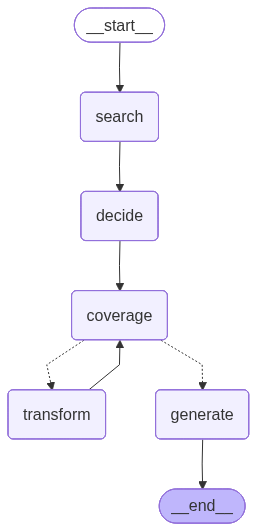

In [23]:
from app.utils.graph import _rag_app

from IPython.display import display, Image

display(Image(_rag_app.get_graph().draw_mermaid_png()))

In [22]:
result['missing']

['توضیح درباره تولید متن به صورت استریم (Streaming RAG)',
 'روش\u200cهای ارزیابی کیفیت پاسخ تولید شده در حالت استریم']

In [26]:
result['child_results']

[ChildSearchResult(score=0.64285713, child_id='10.1', child_title='نتیجه گیری', child_content='RAG   یک معماری قدرتمند است که شکاف بین توانایی های مدل های زبانی بزرگ و نیازهای واقعی\nسازمان ها را پر می کند. با استفاده از این رویکرد می توان سیستم هایی ساخت که نه تنها بر دانش عمومی\nتکیه دارند، بلکه از داده های اختصاصی سازمان نیز به صورت دقیق و مستند استفاده می کنند.\nبا رعایت اصول مربوط به زبان فارسی، انتخاب مدل های مناسب، طراحی درست pipeline   و ارزیابی\nمستمر، می توان سیستم های RAG با کیفیت باال برای کاربران فارسی زبان توسعه داد.', parent_id='10', parent_title='نتیجه گیری', parent_content='\nRAG   یک معماری قدرتمند است که شکاف بین توانایی های مدل های زبانی بزرگ و نیازهای واقعی\nسازمان ها را پر می کند. با استفاده از این رویکرد می توان سیستم هایی ساخت که نه تنها بر دانش عمومی\nتکیه دارند، بلکه از داده های اختصاصی سازمان نیز به صورت دقیق و مستند استفاده می کنند.\nبا رعایت اصول مربوط به زبان فارسی، انتخاب مدل های مناسب، طراحی درست pipeline   و ارزیابی\nمستمر، می توان سیستم های RAG با کیفی

In [35]:
result = decide_context("درباره اجزای رگ توضیح بده و بگو مشکلات زبان فارسی در این سیستم ها چیه ؟", unique_results)
print_decision_result(result)

Parent IDs : ['2', '3']
Context نهایی:
------------------------------------------------------------
### [2] اجزای اصلی یک سیستم   RAG

یک سیستم RAG   از چندین مؤلفه کلیدی تشکیل شده است که هر یک نقش مهمی در کیفیت نهایی
پاسخ ها ایفا می کنند.
۲.۱  پردازش و بارگذاری اسناد   (Document Ingestion)
اولین گام در ساخت یک سیستم RAG، آماده سازی و بارگذاری اسناد است. در این مرحله، متن خام از
اسناد استخراج شده، پاک سازی می شود و برای مراحل بعدی آماده می گردد.
اسناد می توانند در قالب های مختلفی مانند PDF   ، Word   ، HTML، متن ساده و حتی پایگاه های داده
ساخت یافته ارائه شوند. پس از استخراج محتوا، داده ها پردازش شده و برای استفاده در مراحل بعدی
سیستم آماده می شوند.
۲.۲  تقسیم بندی متن (Chunking)
پس از بارگذاری اسناد، متن ها به قطعات کوچک تری به نامChunk تقسیم می شوند. این کار به دلیل
محدودیت پنجره زمینه (Context Window) مدل های زبانی ضروری است.
استراتژی های متداول تقسیم بندی عبارت اند از:
الف) تقسیم بندی با اندازه ثابت (Fixed-size Chunking)
در این روش، متن به قطعاتی با تعداد ثابتی از کاراکترها یا توکن

In [ ]:
from app.utils.graph import run_query

query = ""

result = run_query(query)



In [29]:
result["attempts"]

0

In [33]:
result["decision_result"]

DecisionResult(decision='CHILD', parent_ids=[], child_ids=['4.3'], context='### [4.3] کیفیت تولید (Generation Quality)\n۴.۲  کیفیت تولید (Generation Quality)\nاین معیار کیفیت پاسخ نهایی تولیدشده توسط مدل زبانی را ارزیابی می کند.\nاز جمله شاخص های رایج برای سنجش کیفیت تولید می توان به موارد زیر اشاره کرد:\n•   BLEU\n•   ROUGE\n•   BERTScore\nعالوه بر این، ارزیابی انسانی (Human Evaluation) نیز نقش مهمی در سنجش کیفیت پاسخ ها دارد.\nچارچوب هایی مانندRAGAS نیز برای ارزیابی خودکار سیستم های RAG توسعه یافته اند و معیارهایی\nنظیر موارد زیر را اندازه گیری می کنند:\nFaithfulness ( صحت استناد)\nAnswer Relevancy (ارتباط پاسخ با سؤال)\nContext Precision (دقت زمینه بازیابی شده)')

In [35]:
result["child_results"]

[ChildSearchResult(score=0.5, child_id='4.3', child_title='کیفیت تولید (Generation Quality)', child_content='۴.۲  کیفیت تولید (Generation Quality)\nاین معیار کیفیت پاسخ نهایی تولیدشده توسط مدل زبانی را ارزیابی می کند.\nاز جمله شاخص های رایج برای سنجش کیفیت تولید می توان به موارد زیر اشاره کرد:\n•   BLEU\n•   ROUGE\n•   BERTScore\nعالوه بر این، ارزیابی انسانی (Human Evaluation) نیز نقش مهمی در سنجش کیفیت پاسخ ها دارد.\nچارچوب هایی مانندRAGAS نیز برای ارزیابی خودکار سیستم های RAG توسعه یافته اند و معیارهایی\nنظیر موارد زیر را اندازه گیری می کنند:\nFaithfulness ( صحت استناد)\nAnswer Relevancy (ارتباط پاسخ با سؤال)\nContext Precision (دقت زمینه بازیابی شده)', parent_id='4', parent_title='معیارهای ارزیابی   RAG', parent_content='\nارزیابی کیفیت یک سیستم RAG از چندین جنبه مختلف انجام می شود.\n۴.۱  دقت بازیابی   (Retrieval Accuracy)\nاین معیار نشان می دهد که آیا سیستم توانسته است قطعات مرتبط را با موفقیت بازیابی کند یا خیر.\nشاخص های متداول در این حوزه عبارت اند از:\n•   Precision@K: دقت در K

In [36]:
result["current_query"]

'برای ارزیابی یک سیستم rag چه معیار هایی وجود داره ؟ تمامشون رو شرح بده'

In [ ]:
from app.utils.MultiQueryRetriever import multi_query_retriever
from app.utils.Decider import decide_context, print_decision_result

query = "تولید پاسخ در لحظه چه کمکی میکند؟"

child_results = multi_query_retriever.invoke(
    {
        "question": query
    }
)

result = decide_context(query, child_results, parents_map)

print_decision_result(result)

تصمیم      : CHILD
Child IDs  : ['2.7']
Context نهایی:
------------------------------------------------------------
### [2.7] ۲.۶    تولید پاسخ (Generation)
۲.۶    تولید پاسخ (Generation)
در مرحله نهایی، سؤال اصلی کاربر به همراه قطعات بازیابی شده به عنوانPrompt   به مدل زبانی بزرگ
ارسال می شود.
ساختار Prompt معموال ً  شامل سه بخش است:
1.    دستورالعمل سیستم (System Prompt)
2.   زمینه یا اطالعات بازیابی شده (Retrieved Context)
3.    سؤال کاربر
مدل زبانی با استفاده از این اطالعات، پاسخی جامع، دقیق و مستند تولید می کند.


In [ ]:
import fitz
PDF_PATH = "/home/son/Desktop/rag/app/data/rag_docs.pdf"

doc = fitz.open(PDF_PATH)

page = doc[0]

data = page.get_text("dict")

print(data.keys())

dict_keys(['width', 'height', 'blocks'])


In [ ]:
for block in data["blocks"]:
    print(block["type"])

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [ ]:
from pprint import pprint
import fitz
PDF_PATH = "/home/son/Desktop/rag/app/data/rag_docs.pdf"

doc = fitz.open(PDF_PATH)

page = doc[0]

data = page.get_text("dict")

pprint(data["blocks"][0])

{'bbox': (442.2699890136719,
          36.922061920166016,
          576.2732543945312,
          65.61934661865234),
 'flags': 0,
 'lines': [{'bbox': (569.6199951171875,
                     36.922061920166016,
                     576.2732543945312,
                     65.61934661865234),
            'dir': (1.0, 0.0),
            'spans': [{'alpha': 255,
                       'ascender': 0.9480000138282776,
                       'bbox': (569.6199951171875,
                                36.922061920166016,
                                576.2732543945312,
                                65.61934661865234),
                       'bidi': 0,
                       'char_flags': 16,
                       'color': 2051705,
                       'descender': -0.48399999737739563,
                       'flags': 0,
                       'font': 'IRKoodak',
                       'origin': (569.6199951171875, 55.91998291015625),
                       'size': 20.040000915527344,
  

In [ ]:
import fitz

doc = fitz.open(PDF_PATH)

page = doc[0]

data = page.get_text("dict")

for block in data["blocks"]:
    for line in block["lines"]:
        for span in line["spans"]:
            print(
                f"{span['size']:5.1f}",
                span["font"],
                repr(span["text"])
            )

 20.0 IRKoodak '۱'
 20.0 IRKoodak ' .'
 20.0 IRKoodak ' مقدمه و پیشینه '
 16.0 IRKoodak 'د'
 16.0 IRKoodak 'ر دنیای امروز، مدل های زبانی بزرگ (LLM) به یکی از پایه'
 16.0 IRKoodak 'های اصلی نرم افزارهای هوشمند تبدیل'
 16.0 IRKoodak 'شده'
 16.0 IRKoodak 'اند. این مدل'
 16.0 IRKoodak 'ها قادرند متون طبیعی را درک کرده، آن'
 16.0 IRKoodak 'ها را تحلیل کنند و پاسخ هایی دقیق و روان'
 16.0 IRKoodak ' تولید نمایند. با این حال، یکی از بزرگ'
 16.0 IRKoodak 'ترین چالش'
 16.0 IRKoodak 'های این مدل'
 16.0 IRKoodak 'ها آن است که دانش آن ها به زمان'
 16.0 IRKoodak 'آموزش محدود می'
 16.0 IRKoodak 'شود و دسترسی مستقیمی به داده'
 16.0 IRKoodak 'های جدید، اختصاصی یا سازمانی ندارند.'
 16.0 IRKoodak ' '
 16.0 IRKoodak ' '
 16.0 IRKoodak 'برای رفع این محدودیت، رویکرد «بازیابی-'
 16.0 IRKoodak ' افزوده تولید» یاRAG (Retrieval-Augmented '
 16.0 IRKoodak 'Generation) '
 16.0 IRKoodak ' مطرح شد. این رویکرد ترکیبی از دو مرحله اصلی است:'
 16.0 IRKoodak ' '
 16.0 IRKoodak '1.'
 16.0 ArialMT ' '
 16.0 IRKoodak 'در م

In [ ]:
block = data["blocks"][0]

print(block.keys())

dict_keys(['type', 'number', 'flags', 'bbox', 'lines'])


In [ ]:
print(len(block["lines"]))

3


In [ ]:
line = block["lines"][0]

print(line.keys())

dict_keys(['spans', 'wmode', 'dir', 'bbox'])


In [ ]:
span = line["spans"][0]

print(span)

{'size': 20.040000915527344, 'flags': 0, 'bidi': 0, 'char_flags': 16, 'font': 'IRKoodak', 'color': 2051705, 'alpha': 255, 'ascender': 0.9480000138282776, 'descender': -0.48399999737739563, 'text': '۱', 'origin': (569.6199951171875, 55.91998291015625), 'bbox': (569.6199951171875, 36.922061920166016, 576.2732543945312, 65.61934661865234)}
